# The Nth Asset \U0001F9E9
### Diversification is free, until it is finished

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

Every fund launch is sold as diversification and every allocation deck has one more line on it
than last year. This notebook builds equal-weight portfolios of every size from one to twelve,
picks the members at random three hundred times over, and measures exactly what the next asset
is worth.

> \U0001F4D3 **This is the plain-language layer.** The closed form, the stopping rules and the
> effective-bets arithmetic are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does adding asset classes reduce risk? | Yes — sharply at first. |
| Where does it stop? | Most of the benefit is in by the fourth or fifth holding. |
| Is there a floor? | Yes, and it is set by the average correlation, not by the number of funds. |
| What matters more, how many or which ones? | **Which ones.** The spread across random five-asset portfolios is wider than the gain from going from five to twelve. |

## 1 · The claim

> *"You need exposure to more asset classes."*

Always true in the limit, and almost never quantified. The question a portfolio actually faces
is not "is diversification good" but "what does the next line item buy, and is it worth the
complexity".

In [2]:
from diversify_n import data, strategy as st

px = data.load_prices()
cash = px[data.CASH]
universe = [t for t in data.UNIVERSE if px[t].notna().sum() > 1000]
rets = st.excess_returns(px[universe], cash).dropna(how="any")
print(f"as-of {data.AS_OF} | {len(universe)} asset classes | "
      f"{rets.index[0].date()} -> {rets.index[-1].date()} ({len(rets):,} sessions)")
corr = rets.corr().to_numpy()
iu = np.triu_indices_from(corr, k=1)
print(f"average pairwise correlation: {corr[iu].mean():.3f}")

as-of 2026-06-30 | 12 asset classes | 2015-10-09 -> 2026-06-30 (2,695 sessions)
average pairwise correlation: 0.353


## 2 · So what?

Every extra holding costs something: a rebalance, a fee, an operational line, and a piece of
somebody's attention. If the twelfth asset removes half a percent of volatility, it should be
held to that standard rather than to the slogan.

## 3 · The teardown

### 3.1 The curve

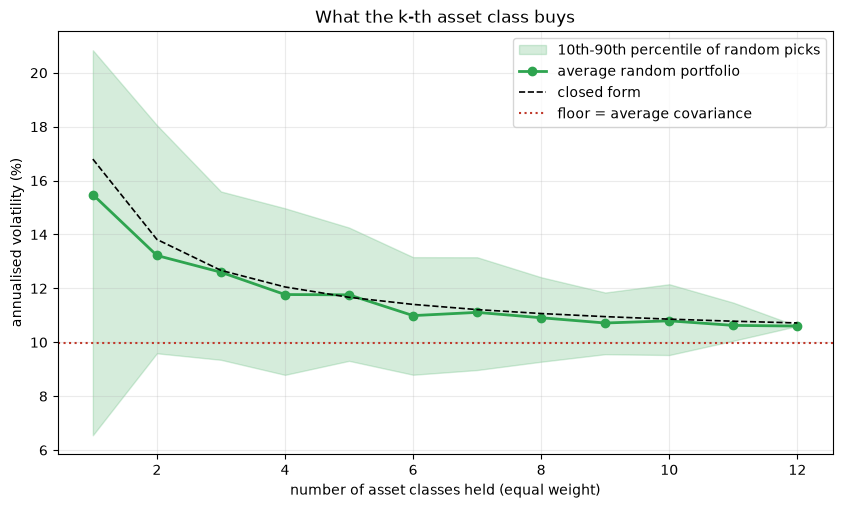

,vol_mean,vol_p10,vol_p90,sharpe_mean,maxdd_mean,draws
k,,,,,,
1,0.1548,0.0655,0.2084,0.3144,-0.3582,200
2,0.1322,0.0959,0.1806,0.4233,-0.3156,200
3,0.1260,0.0935,0.1560,0.4889,-0.2890,200
4,0.1177,0.0879,0.1497,0.4959,-0.2733,200
5,0.1176,0.0931,0.1426,0.5167,-0.2684,200
6,0.1099,0.0879,0.1316,0.5261,-0.2528,200
7,0.1111,0.0897,0.1315,0.5278,-0.2523,200
8,0.1091,0.0928,0.1241,0.5438,-0.2439,200
9,0.1072,0.0956,0.1185,0.5368,-0.2388,200


In [3]:
curve = st.random_subset_curve(rets, draws=200, cost_bps=5.0)
theory = st.theoretical_curve(rets)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(curve.index, curve["vol_p10"] * 100, curve["vol_p90"] * 100,
                color="#2ea44f", alpha=0.20, label="10th-90th percentile of random picks")
ax.plot(curve.index, curve["vol_mean"] * 100, marker="o", color="#2ea44f", lw=2,
        label="average random portfolio")
ax.plot(theory.index, theory["vol_theory"] * 100, ls="--", color="k", lw=1.2,
        label="closed form")
ax.axhline(theory.attrs["floor_vol"] * 100, color="#c0392b", ls=":", lw=1.5,
           label="floor = average covariance")
ax.set_xlabel("number of asset classes held (equal weight)")
ax.set_ylabel("annualised volatility (%)")
ax.set_title("What the k-th asset class buys")
ax.legend()
plt.show()
curve.round(4)

> \U0001F52C **For the quants.** The dashed line is `σ²/k + ρσ²(k−1)/k` with this sample's own
> average variance and correlation. It sits on top of the empirical curve, which is the sign
> that nothing beyond average correlation is doing any work.

### 3.2 The shaded band is the real lesson

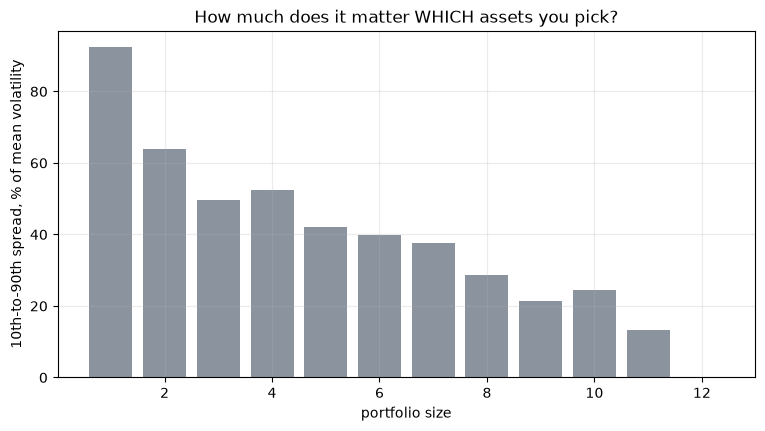

at k = 5: mean vol 11.76%, but the 10th-90th range runs 9.31% to 14.26%
going from 5 assets to all 12 buys 9.9% of volatility


In [4]:
spread = (curve["vol_p90"] - curve["vol_p10"]) / curve["vol_mean"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(spread.index, spread * 100, color="#8b949e")
ax.set_xlabel("portfolio size"); ax.set_ylabel("10th-to-90th spread, % of mean volatility")
ax.set_title("How much does it matter WHICH assets you pick?")
plt.show()
k5 = min(5, curve.index.max())
print(f"at k = {k5}: mean vol {curve.loc[k5, 'vol_mean']:.2%}, "
      f"but the 10th-90th range runs {curve.loc[k5, 'vol_p10']:.2%} to "
      f"{curve.loc[k5, 'vol_p90']:.2%}")
print(f"going from {k5} assets to all {curve.index.max()} buys "
      f"{1 - curve['vol_mean'].iloc[-1] / curve.loc[k5, 'vol_mean']:.1%} of volatility")

### 3.3 Twelve funds, how many bets?

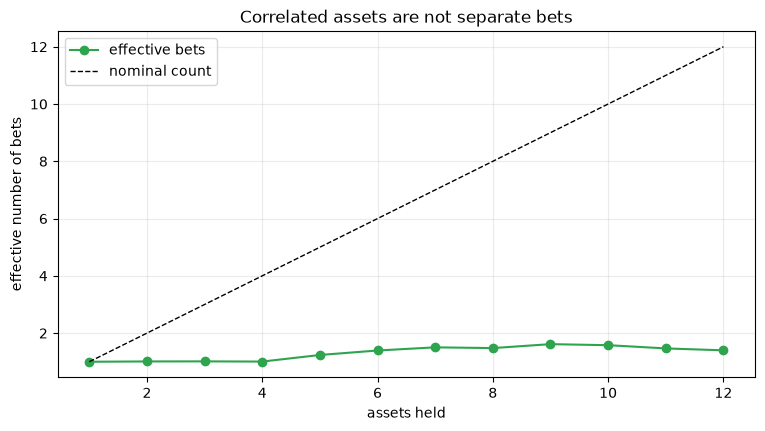

12 nominal assets = 1.40 effective bets


In [5]:
enb = pd.Series({k: st.effective_number_of_bets(rets[universe[:k]])
                 for k in range(1, len(universe) + 1)})
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(enb.index, enb.values, marker="o", color="#2ea44f", label="effective bets")
ax.plot(enb.index, enb.index, ls="--", color="k", lw=1, label="nominal count")
ax.set_xlabel("assets held"); ax.set_ylabel("effective number of bets")
ax.set_title("Correlated assets are not separate bets")
ax.legend()
plt.show()
print(f"{len(universe)} nominal assets = {enb.iloc[-1]:.2f} effective bets")

## 4 · The verdict

**Signal: Real.** A single randomly chosen asset from this universe ran **15.4%** annualised volatility; an equal-weight portfolio of all 12 runs **10.6%** — a **31%** reduction. The empirical curve tracks the textbook one (sigma^2 = sigma^2/k + rho·sigma^2·(k−1)/k) closely: average pairwise correlation is **0.35**, which puts the theoretical floor at **10.0%** — and the twelve-asset portfolio is already within 0.6% of it.

**Usefulness: Fragile.** Yes, and it is smaller than the industry implies. The third asset removes **9.0%** of the portfolio's volatility; the twelfth removes **0.6%**. At a 5% relative-improvement threshold the curve stops paying at **k = 3**; at 2% it stops at **k = 7**. And the count that matters is not the nominal one: 12 assets here are worth **1.4 effective bets**. Choosing well beats choosing many — the best 3-asset combination reached **6.2%** against **12.4%** for a random one of the same size.

## 5 · Going further \U0001F6AA

- **The crisis version.** Correlations rise when it matters; a downside-conditional curve is
  flatter and less comforting.
- **Weighting instead of counting**: risk parity and minimum variance reach the floor with
  fewer assets (studies 976 and 977).
- **Inside one asset class**: the same question for individual stocks is the Evans-Archer
  problem, and this desk's study 1007.